In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [2]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['NanumGothic']


In [3]:
df = pd.read_csv('18_열처리.csv')
print(df.shape)
df.info() # 컬럼의 성격(숫자형/범주형)파악
print(df.isna().sum().sum()) # 결측 존재여부 확인

(297, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   라인      297 non-null    object 
 1   소입로온도   297 non-null    float64
 2   제어출력    297 non-null    float64
 3   건조출력    297 non-null    float64
 4   세정기     297 non-null    float64
 5   CP값     297 non-null    float64
 6   판정      297 non-null    object 
dtypes: float64(5), object(2)
memory usage: 16.4+ KB
0


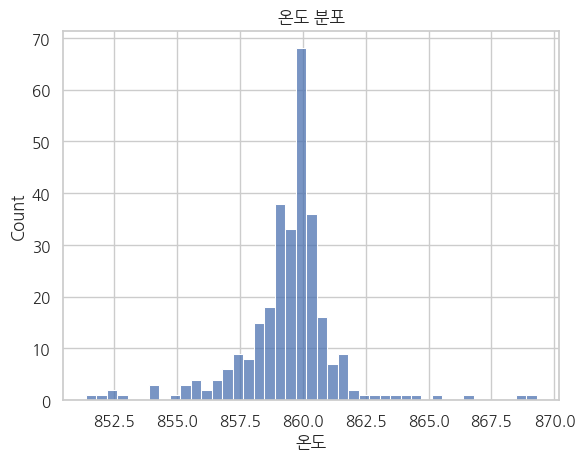

In [4]:
sns.histplot(data = df, x = '소입로온도')
plt.title('온도 분포')
plt.xlabel('온도')
plt.show()

## 실습 1. 첫 분포 그래프 그리기
histplot으로 한 센서의 분포를 그리고 축·제목 완성

목표
- histplot으로 한 센서의 분포를 그리고 완성

단계
- data와 x에 볼 컬럼을 지정해 histplot 그리기
- 제목과 가로·세로축 이름 달기
- 값이 어디에 몰려 있는지 분포 모양 확인

예상 결과
- 전류값이 몰린 구간을 보여 주는 종 모양 분포

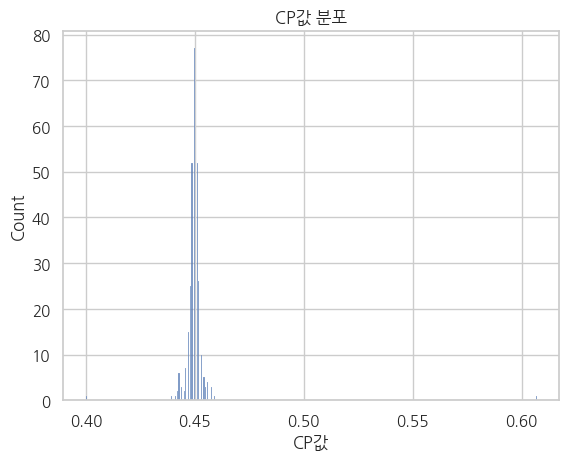

In [5]:
sns.histplot(data = df, x = 'CP값')
plt.title('CP값 분포')
plt.xlabel('CP값')
plt.show()

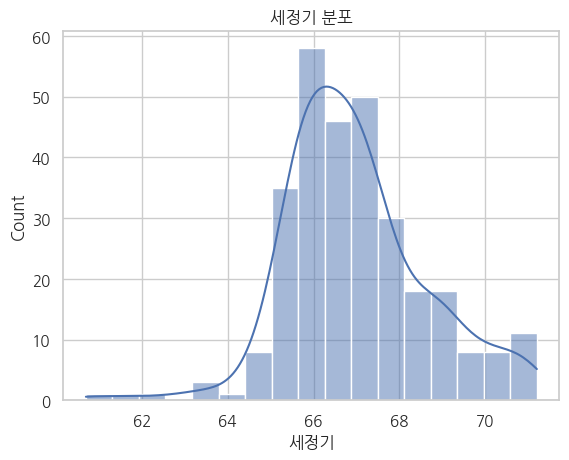

In [6]:
sns.histplot(data = df, x = '세정기', bins=17, kde=True)
plt.title('세정기 분포')
plt.xlabel('세정기')
plt.show()

## 실습 2. bins·kde 조절
bins로 구간 수를, kde로 분포 곡선을 조절

목표
- bins로 구간 수를, kde로 분포 곡선을 조절

단계
- bins 값을 여러 개로 바꿔 가며 분포 그리기
- 구간 수에 따라 막대가 굵어지고 잘게 나뉘는 변화 관찰
- kde 곡선을 더해 분포 모양을 부드럽게 확인

예상 결과
- bins 10·20·40에 따른 전류 분포 모양 차이

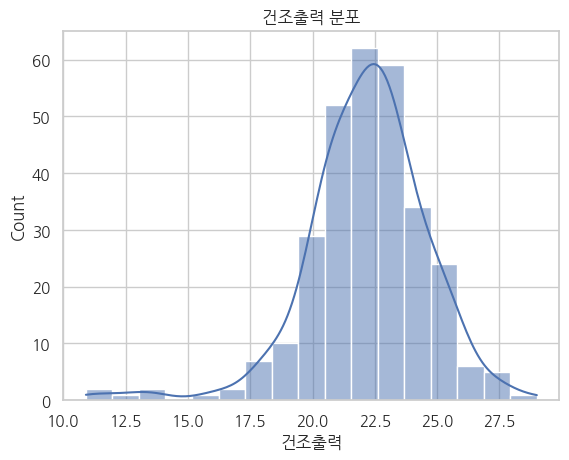

In [7]:
sns.histplot(data = df, x = '건조출력', bins=17, kde=True)
plt.title('건조출력 분포')
plt.xlabel('건조출력')
plt.show()

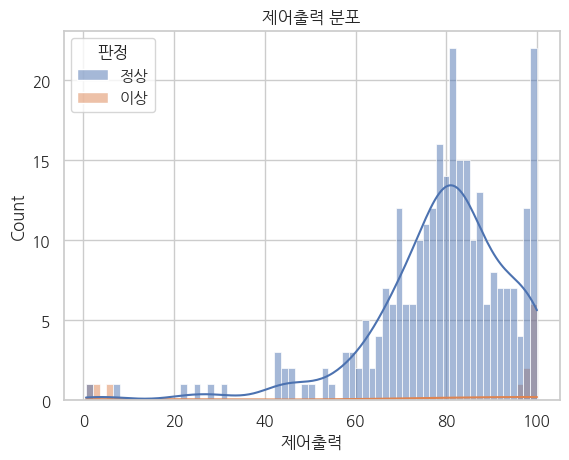

In [8]:
sns.histplot(data = df, x = '제어출력', hue='판정', bins=67, kde=True)
plt.title('제어출력 분포')
plt.xlabel('제어출력')
plt.show()

## 실습 3. 양품·불량 분포 비교
hue로 판정별 분포를 색으로 겹쳐 비교

목표
- hue로 판정별 분포를 색으로 겹쳐 비교

단계
- x에 온도, hue에 판정을 지정해 histplot 그리기
- kde를 더해 두 그룹의 분포 모양 비교
- 불량이 어느 쪽으로 치우쳤는지 확인

예상 결과
- 양품·불량 온도 분포가 색으로 겹쳐 표시

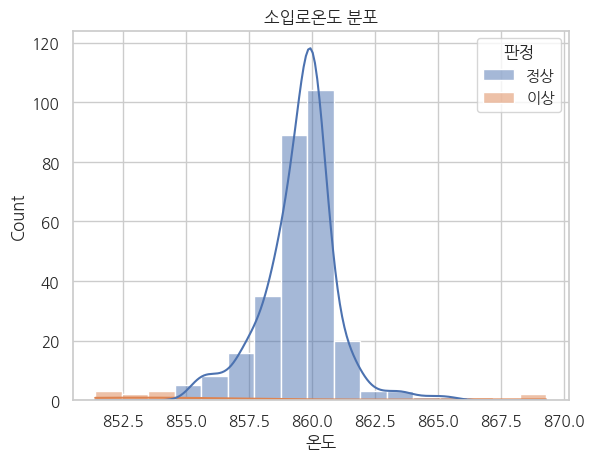

In [9]:
sns.histplot(data = df, x = '소입로온도', hue='판정', bins=17, kde=True)
plt.title('소입로온도 분포')
plt.xlabel('온도')
plt.show()

## 실습 4. 여러 센서 분포 한눈에 보기
반복문으로 여러 센서 분포를 차례로 그리기

목표
- 반복문으로 여러 센서의 분포를 차례로 그려 비교

단계
- 컬럼과 단위 목록을 반복하며 각 센서 분포 그리기
- 각 그래프에 컬럼 이름과 단위로 제목·축 달기
- 센서마다 값이 몰린 정상 범위를 정리

예상 결과
- 온도·진동·전류 분포를 차례로 확인

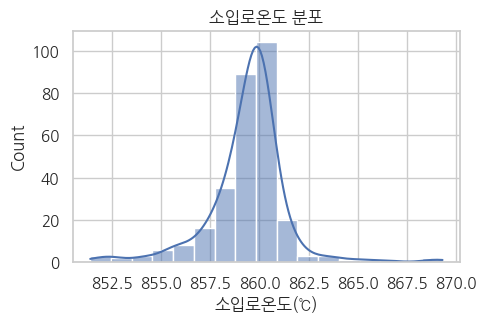

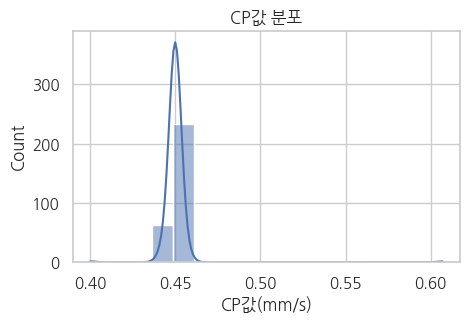

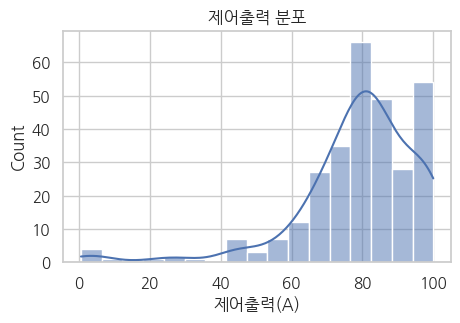

In [13]:
sensors = [
    ('소입로온도', '℃'),
    ('CP값', 'mm/s'),
    ('제어출력', 'A')
]

for col, unit in sensors:
  plt.figure(figsize=(5,3))
  sns.histplot(data=df, x=col, bins=17, kde=True)
  plt.title(f'{col} 분포')
  plt.xlabel(f'{col}({unit})')
  plt.show()

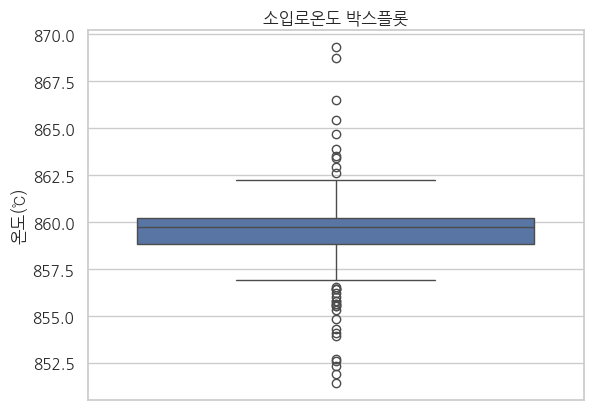

In [17]:
# 간단한 박스플롯

sns.boxplot(data=df, y='소입로온도')
plt.title('소입로온도 박스플롯')
plt.ylabel('온도(℃)')
plt.show()

## 실습 5. 단일 센서 박스플롯
boxplot으로 한 센서의 사분위수·이상치 확인

목표
- boxplot으로 한 센서의 사분위수와 이상치 확인

단계
- y에 볼 센서를 지정해 박스플롯 그리기
- 상자(가운데 절반)와 수염, 이상치 점 위치 확인
- 제목·축 이름 붙이기

예상 결과
- 전류의 상자·수염과 위쪽 이상치 점

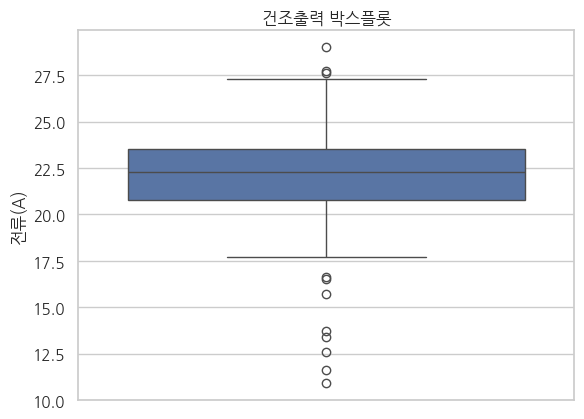

In [19]:
sns.boxplot(data=df, y='건조출력')
plt.title('건조출력 박스플롯')
plt.ylabel('전류(A)')
plt.show()

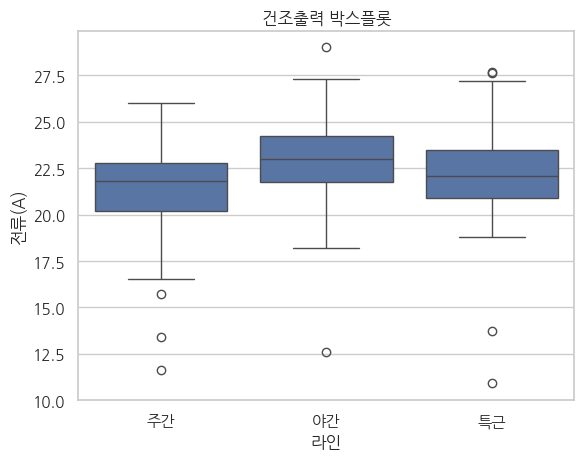

In [20]:
# 범주별 박스플롯
sns.boxplot(data=df, x='라인', y='건조출력')
plt.title('건조출력 박스플롯')
plt.ylabel('전류(A)')
plt.show()

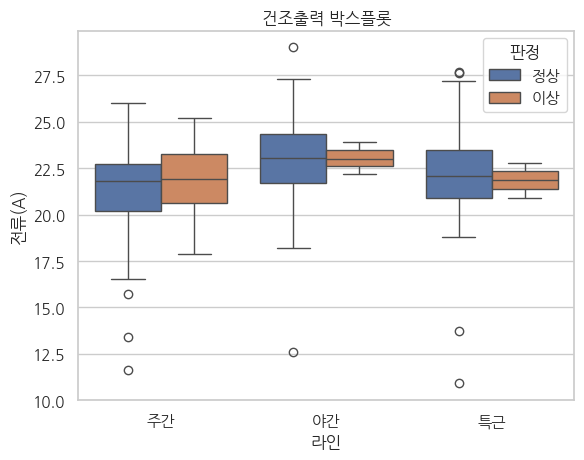

In [21]:
# hue로 두 기준 동시 비교
sns.boxplot(data=df, x='라인', y='건조출력', hue='판정')
plt.title('건조출력 박스플롯')
plt.ylabel('전류(A)')
plt.show()

## 실습 6. 범주별 박스플롯 비교
라인별, 그리고 라인×판정 교차로 분포 비교

목표
- x에 범주를, hue에 판정을 더해 범주별 분포 비교

단계
- x에 설비라인을 지정해 라인별 상자를 나란히 그리기
- hue에 판정을 더해 라인마다 양품·불량 상자 비교
- 일관된 패턴이 신뢰할 신호임을 확인

예상 결과
- 라인별 온도 상자, 그리고 라인×판정 교차 비교

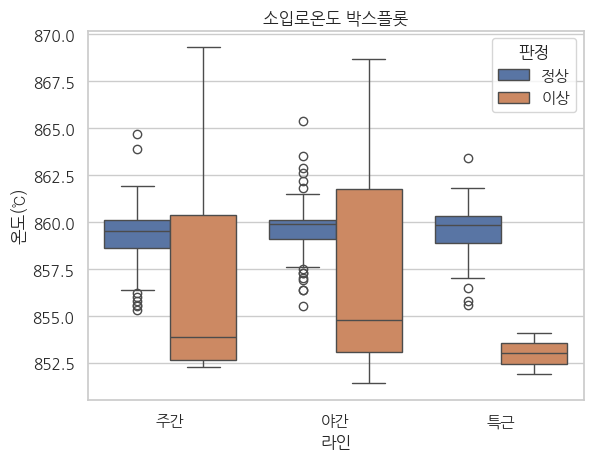

In [22]:
sns.boxplot(data=df, x='라인', y='소입로온도', hue='판정')
plt.title('소입로온도 박스플롯')
plt.ylabel('온도(℃)')
plt.show()

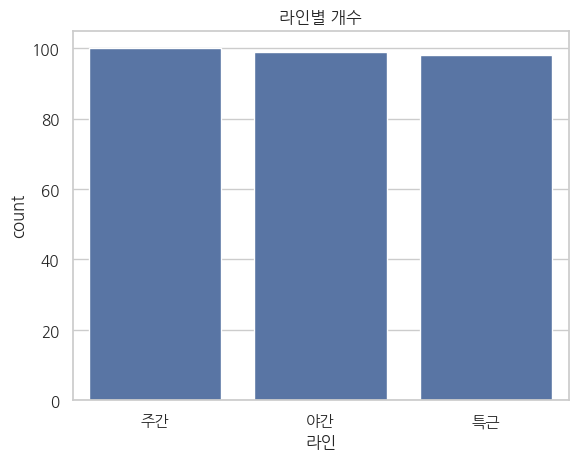

In [26]:
# countplot으로 개수 비교
sns.countplot(data=df, x='라인')
plt.title('라인별 개수')
plt.show()

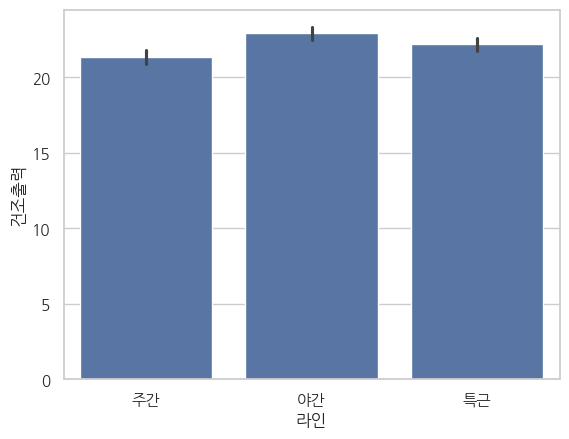

In [32]:
# barplot으로 평균 비교
sns.barplot(data=df, x='라인', y='건조출력')
plt.show()

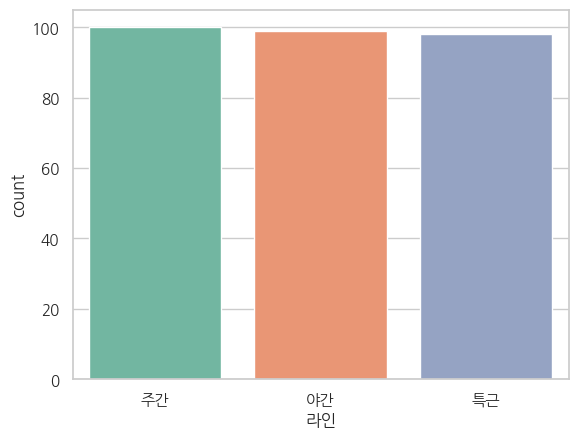

In [44]:
# palette와 hue 함께 쓰는 법

# 팔레트 종류는 다음의 웹사이트 참고
# https://seaborn.pydata.org/generated/seaborn.color_palette.html#seaborn.color_palette$0

# legend=False
# X축에 이미 범례에 해당하는 내용들이 자리잡아서 중복 내용 표기 금지시킴!

sns.countplot(data=df, x='라인', hue='라인', palette='Set2', legend=False)
plt.show()

## 실습 7. countplot·barplot
개수는 countplot, 평균은 barplot으로 범주 비교

목표
- 개수는 countplot, 평균은 barplot으로 범주 비교

단계
- countplot으로 라인별 데이터 개수를 막대로 세기
- barplot으로 라인별 평균 전류를 막대로 비교
- 색은 hue와 palette로 지정(범례는 끄기)

예상 결과
- 라인별 개수와 라인별 평균 전류 막대

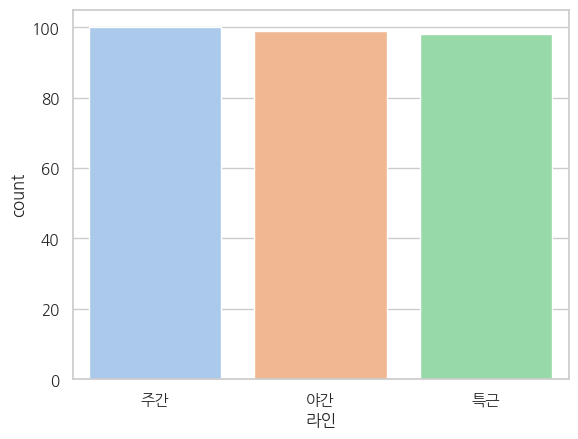

In [53]:
sns.countplot(data=df, x='라인', hue='라인', palette='pastel', legend=False)
plt.show()

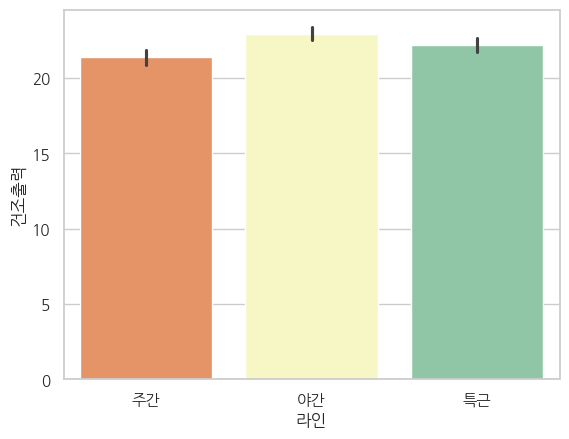

In [50]:
sns.barplot(data=df, x='라인', y='건조출력', hue='라인', palette='Spectral', legend=False)
plt.show()

## 실습 8. 라인별 불량 비율 비교
라인별 양품·불량 개수를 그래프와 표로 정리

목표
- 라인별 양품·불량 개수를 그래프와 표로 정리

단계
- countplot에 hue로 판정을 넣어 라인별 양품·불량 개수 비교
- ~groupby와 unstack으로 라인×판정 개수 표 만들기~
- 불량이 상대적으로 많은 라인 확인

예상 결과
- 라인별 양품·불량 막대와 개수 표(A라인 불량 30 등)

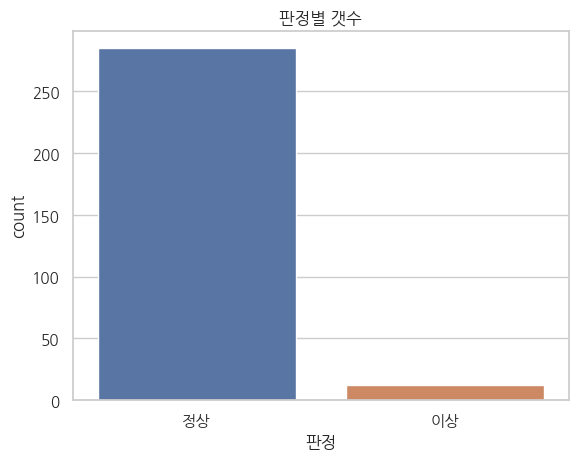

In [55]:
sns.countplot(data=df, x='판정', hue='판정')
plt.title('판정별 갯수')
plt.show()